In [ ]:
"""
CBIS-DDSM 良性 vs 惡性二分類 CNN
================================
- 模型：ResNet50（ImageNet 預訓練）→ 微調 layer4 + 新分類頭
- 切分：病人層級（P_XXXXX），避免醫學影像最常見的資料洩漏
- 影像：使用 roi_cropped.png（裁切後的病灶區域）

如何使用
--------
本機執行：
    py C:\\Users\\s9988\\Documents\\cbis_ddsm_cnn.py

Google Colab：
    1. 上傳這個 .py 檔到 Colab（File → Upload notebook，可直接選 .py）
    2. Runtime → Change runtime type → GPU
    3. Run all
       (執行時會要求你上傳 kaggle.json，並自動下載資料集)
"""

In [ ]:
import os
import sys
import random
from pathlib import Path
from collections import Counter

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

============================================================
1. 環境偵測 + 資料路徑
============================================================

In [ ]:
IN_COLAB = "google.colab" in sys.modules

In [ ]:
if IN_COLAB:
    DATA_ROOT = Path("/content/data/CBIS_DDSM_Kaggle")
    if not DATA_ROOT.exists():
        from google.colab import files
        kaggle_dir = Path.home() / ".kaggle"
        kaggle_dir.mkdir(exist_ok=True)
        if not (kaggle_dir / "kaggle.json").exists():
            print("請上傳你的 kaggle.json：")
            uploaded = files.upload()
            Path("kaggle.json").rename(kaggle_dir / "kaggle.json")
            os.chmod(kaggle_dir / "kaggle.json", 0o600)
        os.system("pip install -q kaggle")
        os.system("kaggle datasets download -d dynemiesizumaki/cbis-ddsmpng "
                  "-p /content/data --unzip")
else:
    DATA_ROOT = Path(r"C:\Users\s9988\Documents\datasets\cbis-ddsm\CBIS_DDSM_Kaggle")

請上傳你的 kaggle.json：


Saving kaggle.json to kaggle.json


In [ ]:
assert DATA_ROOT.exists(), f"找不到資料集: {DATA_ROOT}"
print(f"資料集路徑: {DATA_ROOT}")

資料集路徑: /content/data/CBIS_DDSM_Kaggle


============================================================
2. 超參數
============================================================

In [ ]:
CONFIG = {
    "image_type": "roi_cropped",   # roi_cropped (建議) 或 full_image
    "img_size":   224,
    "batch_size": 32,
    "num_epochs": 15,
    "lr":         1e-4,
    "weight_decay": 1e-4,
    "val_split":  0.15,
    "test_split": 0.15,
    "num_workers": 2 if IN_COLAB else 0,
    "seed":       42,
}

In [ ]:
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


============================================================
3. 掃描資料夾 → DataFrame (path, label, patient_id)
============================================================

In [ ]:
def scan_dataset(root: Path, image_type: str) -> pd.DataFrame:
    rows = []
    label_map = {"BENIGN": 0, "MALIGNANT": 1}
    target = f"{image_type}.png"
    for class_name, label in label_map.items():
        class_dir = root / class_name
        if not class_dir.exists():
            continue
        for case_dir in class_dir.iterdir():
            if not case_dir.is_dir():
                continue
            img_path = case_dir / target
            if not img_path.exists():
                continue
            parts = case_dir.name.split("_")
            patient_id = f"{parts[0]}_{parts[1]}"   # 例如 P_00007
            rows.append({
                "path":       str(img_path),
                "label":      label,
                "patient_id": patient_id,
                "case_id":    case_dir.name,
                "class":      class_name,
            })
    return pd.DataFrame(rows)

In [ ]:
df = scan_dataset(DATA_ROOT, CONFIG["image_type"])
print(f"\n總影像數: {len(df)}")
print(f"類別分布:\n{df['class'].value_counts()}")
print(f"獨立病人數: {df['patient_id'].nunique()}")


總影像數: 495
類別分布:
class
BENIGN       285
MALIGNANT    210
Name: count, dtype: int64
獨立病人數: 429


============================================================
4. 病人層級 train/val/test 切分（避免資料洩漏）
============================================================

In [ ]:
def patient_split(df, val_size, test_size, seed):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trainval_idx, test_idx = next(gss1.split(df, groups=df["patient_id"]))
    df_tv = df.iloc[trainval_idx].reset_index(drop=True)
    df_te = df.iloc[test_idx].reset_index(drop=True)

    val_ratio = val_size / (1.0 - test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss2.split(df_tv, groups=df_tv["patient_id"]))
    return (df_tv.iloc[train_idx].reset_index(drop=True),
            df_tv.iloc[val_idx].reset_index(drop=True),
            df_te)

In [ ]:
df_train, df_val, df_test = patient_split(
    df, CONFIG["val_split"], CONFIG["test_split"], CONFIG["seed"]
)
print(f"\nTrain: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"Train: {df_train['class'].value_counts().to_dict()}")
print(f"Val:   {df_val['class'].value_counts().to_dict()}")
print(f"Test:  {df_test['class'].value_counts().to_dict()}")


Train: 345 | Val: 77 | Test: 73
Train: {'BENIGN': 199, 'MALIGNANT': 146}
Val:   {'BENIGN': 44, 'MALIGNANT': 33}
Test:  {'BENIGN': 42, 'MALIGNANT': 31}


In [ ]:
# 確保沒有病人洩漏
assert not (set(df_train["patient_id"]) & set(df_val["patient_id"]))
assert not (set(df_train["patient_id"]) & set(df_test["patient_id"]))
assert not (set(df_val["patient_id"]) & set(df_test["patient_id"]))
print("病人切分驗證通過 ✓")

病人切分驗證通過 ✓


============================================================
5. Dataset + Transforms
============================================================

In [ ]:
class CBISDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [ ]:
train_tfm = T.Compose([
    T.Resize((CONFIG["img_size"] + 32, CONFIG["img_size"] + 32)),
    T.RandomCrop(CONFIG["img_size"]),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
eval_tfm = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
train_ds = CBISDataset(df_train, train_tfm)
val_ds   = CBISDataset(df_val,   eval_tfm)
test_ds  = CBISDataset(df_test,  eval_tfm)

In [ ]:
mk_loader = lambda ds, shuffle: DataLoader(
    ds, batch_size=CONFIG["batch_size"], shuffle=shuffle,
    num_workers=CONFIG["num_workers"], pin_memory=True,
)
train_loader = mk_loader(train_ds, True)
val_loader   = mk_loader(val_ds,   False)
test_loader  = mk_loader(test_ds,  False)

============================================================
6. ResNet50 Transfer Learning
============================================================

In [ ]:
def build_model(num_classes=2):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():     # 解凍最後一個 stage
        p.requires_grad = True
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model

In [ ]:
model = build_model(2).to(device)
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"\n可訓練參數: {n_train:,} / 總參數: {n_total:,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]



可訓練參數: 14,968,834 / 總參數: 23,512,130


============================================================
7. Loss + Optimizer（含類別不平衡權重）
============================================================

In [ ]:
cnt = Counter(df_train["label"].tolist())
total = sum(cnt.values())
class_weights = torch.tensor(
    [total / (2 * cnt[i]) for i in [0, 1]], dtype=torch.float
).to(device)
print(f"類別權重 (BENIGN, MALIGNANT): {class_weights.cpu().tolist()}")

類別權重 (BENIGN, MALIGNANT): [0.8668341636657715, 1.181506872177124]


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["num_epochs"]
)

============================================================
8. 評估函式 + 訓練迴圈
============================================================

In [ ]:
def evaluate(model, loader):
    model.eval()
    labels, probs, preds = [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
            p = torch.softmax(logits, 1)[:, 1]
            labels.extend(y.cpu().tolist())
            probs.extend(p.cpu().tolist())
            preds.extend(logits.argmax(1).cpu().tolist())
    return {
        "loss":  total_loss / len(loader.dataset),
        "acc":   float(np.mean(np.array(labels) == np.array(preds))),
        "auc":   roc_auc_score(labels, probs) if len(set(labels)) > 1 else float("nan"),
        "labels": labels, "probs": probs, "preds": preds,
    }

In [ ]:
best_auc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}
CKPT = "best_model.pt"

In [ ]:
print("\n=== 開始訓練 ===")
for epoch in range(1, CONFIG["num_epochs"] + 1):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    scheduler.step()

    tr_loss = running / len(train_ds)
    vm = evaluate(model, val_loader)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vm["loss"])
    history["val_acc"].append(vm["acc"])
    history["val_auc"].append(vm["auc"])

    flag = ""
    if vm["auc"] > best_auc:
        best_auc = vm["auc"]
        torch.save(model.state_dict(), CKPT)
        flag = " ← saved"
    print(f"Epoch {epoch:02d}/{CONFIG['num_epochs']:02d} | "
          f"train_loss={tr_loss:.4f} | val_loss={vm['loss']:.4f} | "
          f"val_acc={vm['acc']:.4f} | val_auc={vm['auc']:.4f}{flag}")


=== 開始訓練 ===
Epoch 01/15 | train_loss=0.6838 | val_loss=0.6925 | val_acc=0.5065 | val_auc=0.4731 ← saved
Epoch 02/15 | train_loss=0.6512 | val_loss=0.6764 | val_acc=0.5714 | val_auc=0.6081 ← saved
Epoch 03/15 | train_loss=0.6394 | val_loss=0.6603 | val_acc=0.6494 | val_auc=0.6364 ← saved
Epoch 04/15 | train_loss=0.6190 | val_loss=0.6438 | val_acc=0.6623 | val_auc=0.6660 ← saved
Epoch 05/15 | train_loss=0.5946 | val_loss=0.6379 | val_acc=0.6753 | val_auc=0.6674 ← saved
Epoch 06/15 | train_loss=0.5831 | val_loss=0.6186 | val_acc=0.6494 | val_auc=0.6997 ← saved
Epoch 07/15 | train_loss=0.5720 | val_loss=0.6224 | val_acc=0.6494 | val_auc=0.6901
Epoch 08/15 | train_loss=0.5651 | val_loss=0.6059 | val_acc=0.6234 | val_auc=0.7080 ← saved
Epoch 09/15 | train_loss=0.5493 | val_loss=0.5992 | val_acc=0.6234 | val_auc=0.7197 ← saved
Epoch 10/15 | train_loss=0.5565 | val_loss=0.5859 | val_acc=0.6623 | val_auc=0.7431 ← saved
Epoch 11/15 | train_loss=0.5604 | val_loss=0.5812 | val_acc=0.6883 | val_a

In [ ]:
print(f"\n最佳 Validation AUC: {best_auc:.4f}")


最佳 Validation AUC: 0.7521


============================================================
9. 載入最佳模型 → Test Set 評估
============================================================

In [ ]:
model.load_state_dict(torch.load(CKPT, map_location=device))
tm = evaluate(model, test_loader)
print(f"\n=== Test Set ===")
print(f"Loss: {tm['loss']:.4f}  Accuracy: {tm['acc']:.4f}  AUC: {tm['auc']:.4f}")
print("\nClassification Report:")
print(classification_report(tm["labels"], tm["preds"],
                            target_names=["BENIGN", "MALIGNANT"]))
print("Confusion Matrix:")
print(confusion_matrix(tm["labels"], tm["preds"]))


=== Test Set ===
Loss: 0.6340  Accuracy: 0.6438  AUC: 0.7289

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.75      0.57      0.65        42
   MALIGNANT       0.56      0.74      0.64        31

    accuracy                           0.64        73
   macro avg       0.66      0.66      0.64        73
weighted avg       0.67      0.64      0.64        73

Confusion Matrix:
[[24 18]
 [ 8 23]]


============================================================
10. 視覺化
============================================================

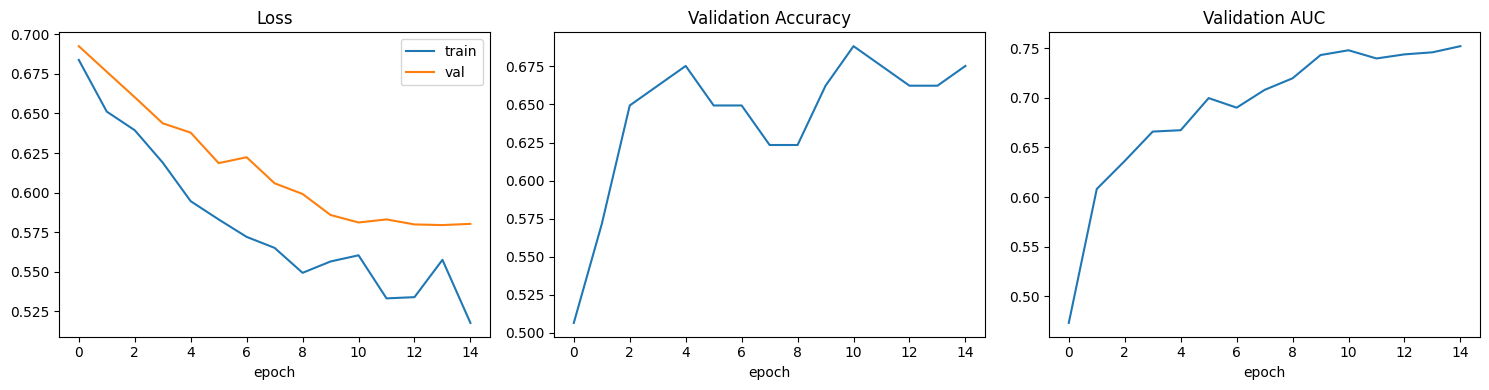

已儲存: best_model.pt, training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["val_acc"])
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("epoch")
axes[2].plot(history["val_auc"])
axes[2].set_title("Validation AUC"); axes[2].set_xlabel("epoch")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()
print("已儲存: best_model.pt, training_curves.png")